#### Zadanie 1 (1pkt)
Ustal losowe (referencyjne) x rozmiaru 1000 oraz losowe A rozmiaru 1000x1000, policz b=A*x.
Nastepnie rozwiąż równanie Ax=b trzema metodami:
- inv()
- \
- factorize()

Porównaj jakość wyniku (zmierzoną jako długość różnicy wektorów wyniku oraz referencyjnego x) oraz czas wykonania (@time). UWAGA: pierwsze wykonanie funkcji w Julii zawiera czas kompilacji tej funkcji, dlatego czas mierzymy  od drugiego wywołania !

#### Zadanie 2 (1pkt)
Policz współczynniki wielomianu aproksymującego dowolne dane z poprzednich laboratoriów tworząc wprost układ równań i rozwiązujac go (metoda z użyciem faktoryzacji QR zaprezentowana na tym laboratorium).
Porównaj wyniki z tymi otrzymanymi poprzednio.

#### Zadanie 3 (2 pkt)

Znajdź i zaprezentuj działanie innego zastosowania wybranej faktoryzacji. Przykładowe (ale nie jedyne!) tematy:

-    tworzenie pseudoinversji macierzy (http://buzzard.ups.edu/courses/2014spring/420projects/math420-UPS-spring-2014-macausland-pseudo-inverse-present.pdf).

-   uzycie faktoryzacji QR do znajdowania wartości własnych (https://en.wikipedia.org/wiki/QR_algorithm)

-  zastosowanie faktoryzacji SVD - np. zastosowania w uczeniu maszynowym 



In [24]:
using Roots,Plots,ForwardDiff,LinearAlgebra,Statistics,DataFrames,CSV,Polynomials
# Długość wektora liczymy jako pierwiastek z jego iloczynu skalarnego.

In [25]:
# Zadanie 1

# Losujemy macierz 1000x1000 
A = rand(1000, 1000)
# losujemy wektor o rozmiarze 1000
x = rand(1000)
# Liczymy b = A*x
b = A*x

1000-element Vector{Float64}:
 253.40484405760236
 247.06928137813622
 249.29739159472746
 252.10576193083378
 248.50733798112756
 253.9741088482233
 246.08726246910462
 250.24399260032342
 255.99283302636155
 246.7546488059826
 246.06589458144217
 248.96500525174963
 244.86005790561128
   ⋮
 241.89173933076484
 246.51759317583878
 256.73739755852694
 258.9725862067964
 247.51954960743095
 239.09486217612397
 258.3344465941859
 256.2359107439215
 237.18721388636052
 250.0386219135691
 241.23101657966484
 261.3123587684842

In [26]:
# DataFrame do zapisywania wyników
results = DataFrame(
    Method = String[],
    Difference = Float64[],
    Time = Float64[]
)

# Rozwiązanie Ax=b trzema metodami (inv, \, factorize()) 
t1 = @elapsed x1 = inv(A) * b
met1 = x - x1
res1 = sqrt(dot(met1, met1))
push!(results, ("inv", res1, t1))

t2 = @elapsed x2 = A \ b
met2 = x - x2
res2 = sqrt(dot(met2, met2))
push!(results, ("\\", res2, t2))

Af = factorize(A)
t3 = @elapsed x3 = Af \ b
met3 = x - x3
res3 = sqrt(dot(met3, met3))
push!(results, ("factorize", res3, t3))

Row,Method,Difference,Time
,String,Float64,Float64
1,inv,5.08265e-11,0.432645
2,\\,2.03994e-11,0.178427
3,factorize,2.03994e-11,0.0010446


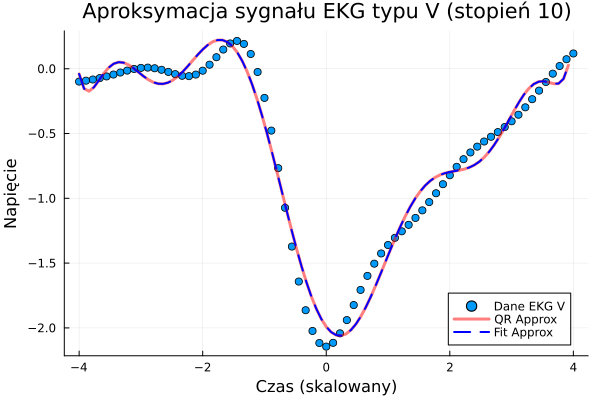

Współczynniki z QR:
[8.58116675065807e-5, -1.8798568578059799e-6, -0.0038015372877054096, 0.0003682463923172536, 0.06183378451683589, -0.011560226745988335, -0.4499937374930993, 0.14039461719304083, 1.4487251731643478, -0.636025784610511, -1.9911671739224097]
Współczynniki z fit:
[-1.9911671739224097, -0.6360257846105104, 1.448725173164344, 0.1403946171930399, -0.449993737493097, -0.011560226745987992, 0.06183378451683542, 0.00036824639231721254, -0.0038015372877053693, -1.8798568578045137e-6, 8.581166750657955e-5]


In [28]:
# Zadanie 2
# Policz współczynniki wielomianu aproksymującego dowolne dane z poprzednich laboratoriów tworząc wprost układ równań i rozwiązujac go 
# (metoda z użyciem faktoryzacji QR zaprezentowana na tym laboratorium). Porównaj wyniki z tymi otrzymanymi poprzednio.

ekg_data = CSV.read("ecg_data.csv", DataFrame);

# Definicja węzłów
xx_ekg = ekg_data.time*40
yy_ekgV = ekg_data.signalV;

# Macierz Vandermonde dla wielomianu 10 stopnia; 
A = zeros(73, 11)
for i in 0:10
    A[:, 11-i] = xx_ekg .^ i
end

A_factorized = factorize(A)
coeffs_QR = A_factorized \ yy_ekgV

poly_QR = Polynomial(reverse(coeffs_QR))

poly_fit = fit(xx_ekg, yy_ekgV, 10)

p = scatter(xx_ekg, yy_ekgV, label="Dane EKG V", xlabel="Czas (skalowany)", ylabel="Napięcie", title="Aproksymacja sygnału EKG typu V (stopień 10)")
plot!(poly_QR, extrema(xx_ekg)..., label="QR Approx", color=:red, linewidth=3, linealpha=0.5)
plot!(poly_fit, extrema(xx_ekg)..., label="Fit Approx", color=:blue, linewidth=2, linestyle=:dash)
display(p)

println("Współczynniki z QR:")
println(coeffs_QR)
println("Współczynniki z fit:")
println(coeffs(poly_fit))

In [31]:
# Zadanie 3
# Znajdź i zaprezentuj działanie innego zastosowania wybranej faktoryzacji.

# Użycie faktoryzacji QR do znajdowania wartości własnych.
# Celem algorytmu jest znalezienie wartości własnych macierzy A.
# Idea algorytmu:
# Zaczynamy od A_0 = A
# Dla każdej iteracji k:
# obliczamy faktoryzację QR:
# A_k = Q_k*R_k; Q_k - macierz ortogonalna, R_k - macierz trójkątna górna
# A_(k+1) = R_k*Q_k = Q_k^(-1)*Q_k*R_k*Q_k = Q_k^(-1)*A_k*Q_k = Q_k^(T)*A_k*Q_k
# Należy zauważyć, że wszystkie A_k są podobne, a zatem mają takie same wartości 
# własne. Algorytm jest numerycznie stabilny, ponieważ postępuje poprzez
# ortogonalne przekształcenia podobieństwa.

In [33]:
# Algorytm 
function QR_algorithm(A, maxiter=1000, tol=1e-10)
    Ak = copy(A)
    for i in 1:maxiter
        Q, R = qr(Ak).Q, qr(Ak).R
        Ak = R * Q
        # Sprawdzamy zbieżność (czy poza przekątną są już zera)
        if norm(Ak - Diagonal(diag(Ak))) < tol
            break
        end
    end
    return diag(Ak)
end

QR_algorithm (generic function with 3 methods)

In [37]:
# Test
A = [4.0 1.0 0.0;
     1.0 3.0 1.0;
     0.0 1.0 2.0]

eigenvalues_qr = QR_algorithm(A)
eigenvalues_builtin = eigvals(A)

println("Wartości własne (QR-algorytm):")
println(sort(eigenvalues_qr))

println("Wartości własne (wbudowana funkcja):")
println(sort(eigenvalues_builtin))

Wartości własne (QR-algorytm):
[1.267949192431124, 2.9999999999999956, 4.732050807568875]
Wartości własne (wbudowana funkcja):
[1.2679491924311228, 3.000000000000001, 4.732050807568877]


In [38]:
# W zadaniu 3 zaprezentowałem zastosowanie faktoryzacji QR do znajdowania 
# wartości własnych macierzy – tzw. QR-algorytm. Jest to klasyczna metoda 
# numeryczna, która iteracyjnie przekształca macierz do postaci trójkątnej, 
# z której można odczytać wartości własne. Porównałem otrzymane wyniki z 
# wbudowaną funkcją eigvals, uzyskując zgodność do wybranej tolerancji numerycznej.